## Step 1 — Setup & Master Schema
We’ll start by defining the **target schema** and a couple of helper utilities for normalization and link extraction. This is the base for all sources.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from typing import List, Dict, Iterable

import pandas as pd

# Target schema columns (order matters for the final CSV)
SCHEMA_COLUMNS = [
    "email_id",
    "source",
    "actual_class",  # 0 legit, 1 phishing
    "sender_address",
    "subject_line",
    "body_content",
    "extracted_links",
]

# Basic URL regex for link extraction
URL_REGEX = re.compile(r"https?://[^\s<>]+", re.IGNORECASE)


def extract_links(text: str) -> List[str]:
    if not text:
        return []
    return URL_REGEX.findall(text)


def normalize_record(
    email_id: str,
    source: str,
    actual_class: int,
    sender_address: str,
    subject_line: str,
    body_content: str,
) -> Dict[str, object]:
    """Return a normalized dict matching the target schema."""
    body_content = body_content or ""
    subject_line = subject_line or ""
    extracted_links = extract_links(body_content)
    return {
        "email_id": email_id,
        "source": source,
        "actual_class": int(actual_class),
        "sender_address": sender_address or "",
        "subject_line": subject_line,
        "body_content": body_content,
        "extracted_links": extracted_links,
    }


def validate_schema(df: pd.DataFrame) -> None:
    missing = [c for c in SCHEMA_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")


def empty_master_frame() -> pd.DataFrame:
    return pd.DataFrame(columns=SCHEMA_COLUMNS)


master_df = empty_master_frame()
master_df.head()

,email_id,source,actual_class,sender_address,subject_line,body_content,extracted_links


## Step 2 — Create a Small Demo Dataset
We’ll mock a few emails (benign, phishing, AI‑benign, AI‑phishing, hybrid). This lets us validate the pipeline before wiring real datasets.

In [2]:
demo_records = [
    normalize_record(
        email_id="EN_001",
        source="Enron",
        actual_class=0,
        sender_address="hr@enron.com",
        subject_line="Updated benefits policy",
        body_content="Please review the updated benefits policy attached.",
    ),
    normalize_record(
        email_id="PB_001",
        source="Phishbowl",
        actual_class=1,
        sender_address="security@paypa1.com",
        subject_line="URGENT: Verify your account now",
        body_content="Dear Customer, verify immediately at https://paypa1-secure.com/login",
    ),
    normalize_record(
        email_id="AI_001",
        source="Kaggle_AI",
        actual_class=0,
        sender_address="support@shop.com",
        subject_line="Your receipt from Shop",
        body_content="Hello Alex, thanks for your purchase. Receipt: https://shop.com/receipt/123",
    ),
    normalize_record(
        email_id="AI_101",
        source="Kaggle_AI",
        actual_class=1,
        sender_address="it@university.edu",
        subject_line="Action required: mailbox quota",
        body_content="Hi user, your mailbox will be closed by EOD. Login: https://university-helpdesk.com",
    ),
    normalize_record(
        email_id="HY_001",
        source="Self_Generated_Hybrid",
        actual_class=1,
        sender_address="services@campus.edu",
        subject_line="Account update for student services",
        body_content="Hello Student, please confirm details at https://campus-services.net/update",
    ),
]

master_df = pd.DataFrame(demo_records, columns=SCHEMA_COLUMNS)
validate_schema(master_df)
master_df

,email_id,source,actual_class,sender_address,subject_line,body_content,extracted_links
0,EN_001,Enron,0,hr@enron.com,Updated benefits policy,Please review the updated benefits policy atta...,[]
1,PB_001,Phishbowl,1,security@paypa1.com,URGENT: Verify your account now,"Dear Customer, verify immediately at https://p...",[https://paypa1-secure.com/login]
2,AI_001,Kaggle_AI,0,support@shop.com,Your receipt from Shop,"Hello Alex, thanks for your purchase. Receipt:...",[https://shop.com/receipt/123]
3,AI_101,Kaggle_AI,1,it@university.edu,Action required: mailbox quota,"Hi user, your mailbox will be closed by EOD. L...",[https://university-helpdesk.com]
4,HY_001,Self_Generated_Hybrid,1,services@campus.edu,Account update for student services,"Hello Student, please confirm details at https...",[https://campus-services.net/update]


## Step 3 — 13‑Cue Labelling (from the PDF)
This implements all 13 cues listed in the plan. Each cue is a binary column, plus a composite `Cue_V_Triad_Score`.

In [3]:
from urllib.parse import urlparse

# Keyword lists for cues
URGENCY_PATTERNS = re.compile(r"\b(urgent|immediately|action required|by eod|asap|within 24 hours)\b", re.I)
GENERIC_GREETING_PATTERNS = re.compile(r"\b(dear customer|valued member|hi user|hello user|dear user)\b", re.I)
PERSONAL_INFO_PATTERNS = re.compile(r"\b(ssn|social security|password|credentials|bank details|account number|otp|pin)\b", re.I)
THREAT_PATTERNS = re.compile(r"\b(account will be closed|suspended|terminated|legal action|permanent deletion)\b", re.I)
EMOTIONAL_PATTERNS = re.compile(r"\b(help me|please help|act now|we care|dear friend)\b", re.I)
TOO_GOOD_PATTERNS = re.compile(r"\b(free|winner|congratulations|claim your prize|limited time)\b", re.I)

BRAND_KEYWORDS = {
    "paypal", "microsoft", "amazon", "apple", "google", "bank", "university",
    "campus", "enron", "shop", "service", "support"
}

COMMON_TYPO_WORDS = {
    "teh", "recieve", "verifiy", "immediatly", "accout", "securtiy",
    "confirmm", "updtae", "lenght", "succesful", "passwrod"
}


def _text_lower(subject: str, body: str) -> str:
    return f"{subject or ''} {body or ''}".lower()


def _sender_domain(sender_address: str) -> str:
    if not sender_address or "@" not in sender_address:
        return ""
    return sender_address.split("@", 1)[1].lower()


def _link_domains(links: List[str]) -> List[str]:
    domains = []
    for link in links:
        try:
            parsed = urlparse(link)
            if parsed.netloc:
                domains.append(parsed.netloc.lower())
        except Exception:
            continue
    return domains


def cue_no_branding(text: str) -> int:
    return 0 if any(k in text for k in BRAND_KEYWORDS) else 1


def cue_overall_design(text: str) -> int:
    # Heuristic: excessive exclamation or too many ALL-CAPS words
    exclaim = text.count("!")
    caps_words = sum(1 for w in re.findall(r"\b[A-Z]{4,}\b", text))
    return 1 if (exclaim >= 3 or caps_words >= 5) else 0


def cue_suspicious_sender(sender_address: str) -> int:
    domain = _sender_domain(sender_address)
    if not domain:
        return 1
    return 1 if (re.search(r"\d", domain) or any(k in domain for k in ["secure", "login", "verify"])) else 0


def cue_no_sender_details(sender_address: str) -> int:
    return 1 if not sender_address or "@" not in sender_address else 0


def cue_generic_greeting(text: str) -> int:
    return 1 if GENERIC_GREETING_PATTERNS.search(text) else 0


def cue_spelling_grammar(text: str) -> int:
    # Lightweight heuristic: count known typos
    words = re.findall(r"[a-zA-Z]+", text.lower())
    typo_hits = sum(1 for w in words if w in COMMON_TYPO_WORDS)
    return 1 if typo_hits > 2 else 0


def cue_urgency(text: str) -> int:
    return 1 if URGENCY_PATTERNS.search(text) else 0


def cue_threats(text: str) -> int:
    return 1 if THREAT_PATTERNS.search(text) else 0


def cue_emotional_appeal(text: str) -> int:
    return 1 if EMOTIONAL_PATTERNS.search(text) else 0


def cue_too_good_true(text: str) -> int:
    return 1 if TOO_GOOD_PATTERNS.search(text) else 0


def cue_personal_info(text: str) -> int:
    return 1 if PERSONAL_INFO_PATTERNS.search(text) else 0


def cue_suspicious_link(sender_address: str, links: List[str]) -> int:
    sender_domain = _sender_domain(sender_address)
    if not links:
        return 0
    link_domains = _link_domains(links)
    # Flag if any link domain does not contain sender domain
    if sender_domain:
        return 1 if any(sender_domain not in d for d in link_domains) else 0
    return 1  # no sender domain but links exist


def label_email_row(row: pd.Series) -> Dict[str, int]:
    text = _text_lower(row.get("subject_line", ""), row.get("body_content", ""))
    sender = row.get("sender_address", "")
    links = row.get("extracted_links", [])

    cues = {
        "Cue_No_Branding": cue_no_branding(text),
        "Cue_Overall_Design": cue_overall_design(row.get("subject_line", "") + " " + row.get("body_content", "")),
        "Cue_Suspicious_Sender": cue_suspicious_sender(sender),
        "Cue_No_Sender_Details": cue_no_sender_details(sender),
        "Cue_Generic_Greeting": cue_generic_greeting(text),
        "Cue_Spelling_Grammar": cue_spelling_grammar(text),
        "Cue_Urgency": cue_urgency(text),
        "Cue_Threats": cue_threats(text),
        "Cue_Emotional_Appeal": cue_emotional_appeal(text),
        "Cue_Too_Good_True": cue_too_good_true(text),
        "Cue_Personal_Info": cue_personal_info(text),
        "Cue_Suspicious_Link": cue_suspicious_link(sender, links),
    }
    cues["Cue_V_Triad_Score"] = sum(cues.values())
    return cues


cue_df = master_df.apply(label_email_row, axis=1, result_type="expand")
labelled_df = pd.concat([master_df, cue_df], axis=1)
labelled_df

,email_id,source,actual_class,sender_address,subject_line,body_content,extracted_links,Cue_No_Branding,Cue_Overall_Design,Cue_Suspicious_Sender,Cue_No_Sender_Details,Cue_Generic_Greeting,Cue_Spelling_Grammar,Cue_Urgency,Cue_Threats,Cue_Emotional_Appeal,Cue_Too_Good_True,Cue_Personal_Info,Cue_Suspicious_Link,Cue_V_Triad_Score
0,EN_001,Enron,0,hr@enron.com,Updated benefits policy,Please review the updated benefits policy atta...,[],1,0,0,0,0,0,0,0,0,0,0,0,1
1,PB_001,Phishbowl,1,security@paypa1.com,URGENT: Verify your account now,"Dear Customer, verify immediately at https://p...",[https://paypa1-secure.com/login],1,0,1,0,1,0,1,0,0,0,0,1,5
2,AI_001,Kaggle_AI,0,support@shop.com,Your receipt from Shop,"Hello Alex, thanks for your purchase. Receipt:...",[https://shop.com/receipt/123],0,0,0,0,0,0,0,0,0,0,0,0,0
3,AI_101,Kaggle_AI,1,it@university.edu,Action required: mailbox quota,"Hi user, your mailbox will be closed by EOD. L...",[https://university-helpdesk.com],0,0,0,0,1,0,1,0,0,0,0,1,3
4,HY_001,Self_Generated_Hybrid,1,services@campus.edu,Account update for student services,"Hello Student, please confirm details at https...",[https://campus-services.net/update],0,0,0,0,0,0,0,0,0,0,0,1,1


## Step 4 — Summary Table (Cue Density Matrix)
Aggregates mean cue counts per source and the % caught using a score threshold.

In [4]:
CUE_COLUMNS = [
    "Cue_No_Branding",
    "Cue_Overall_Design",
    "Cue_Suspicious_Sender",
    "Cue_No_Sender_Details",
    "Cue_Generic_Greeting",
    "Cue_Spelling_Grammar",
    "Cue_Urgency",
    "Cue_Threats",
    "Cue_Emotional_Appeal",
    "Cue_Too_Good_True",
    "Cue_Personal_Info",
    "Cue_Suspicious_Link",
]

# Total cues per email
labelled_df["cue_total"] = labelled_df[CUE_COLUMNS].sum(axis=1)

# Summary by source
summary = (
    labelled_df.groupby("source")
    .agg(
        avg_cues=("cue_total", "mean"),
        top_cue=(
            "cue_total",
            lambda s: labelled_df.loc[s.index, CUE_COLUMNS].mean().idxmax(),
        ),
        pct_caught=("cue_total", lambda s: (s > 3).mean() * 100),
        count=("cue_total", "size"),
    )
    .reset_index()
)

summary

,source,avg_cues,top_cue,pct_caught,count
0,Enron,1.0,Cue_No_Branding,0.0,1
1,Kaggle_AI,1.5,Cue_Generic_Greeting,0.0,2
2,Phishbowl,5.0,Cue_No_Branding,100.0,1
3,Self_Generated_Hybrid,1.0,Cue_Suspicious_Link,0.0,1


## Step 5 — Quick Visualization
Bar chart of average cue totals per source for the demo.

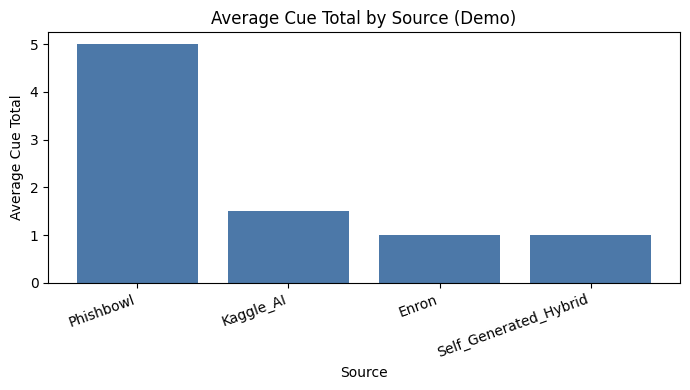

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
summary_sorted = summary.sort_values("avg_cues", ascending=False)
plt.bar(summary_sorted["source"], summary_sorted["avg_cues"], color="#4C78A8")
plt.title("Average Cue Total by Source (Demo)")
plt.ylabel("Average Cue Total")
plt.xlabel("Source")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()